In [1]:
#Imports
import pandas as pd
from Span_dist_alpha import alpha_span_dist
from Span_dist_forces import forces_span_dist
from Span_dist_inductions import induction_span_dist
import numpy as np

U0 = 60
rho  = 1.007
d = 0.7*2

In [2]:
# Our code total results
df = pd.read_csv('results.csv')
Pc = df["Total Power"] / (rho * U0**3 * (0.7*2)**2)
df["eta_harv"] = -Pc * 8/np.pi
df['eta'] = (df["J"] * df["CT"]/df["CP"])
print(df.head())


# dfEXPres

     R         J  Total Thrust  Total Torque  Total Power         CT  \
0  0.7  1.333333     12.719152   -142.679927  -480.259510  11.463718   
1  0.7  1.666667     12.719225   -142.680542  -384.209264  17.912162   
2  0.7  2.000000     12.719265   -142.680876  -320.175138  25.793594   
3  0.7  2.333333     12.719290   -142.681079  -274.436222  35.108015   
4  0.7  2.666667     12.719305   -142.681210  -240.131915  45.855423   

           CQ           CP  eta_harv       eta  
0  -91.854864  -171.462413  0.002869 -0.089145  
1 -143.523844  -334.888969  0.002295 -0.089145  
2 -206.674820  -578.689496  0.001912 -0.089145  
3 -281.307793  -918.938790  0.001639 -0.089145  
4 -367.422761 -1371.711642  0.001434 -0.089145  


In [3]:
#Java Prop validation data for whole propeller
csv_file_path = 'JavaPropValMulti.csv'
dfs = pd.read_csv(csv_file_path, sep=r"\s+")
dfs = dfs.drop([0]) #drop the second row
dfs = dfs.rename(columns={'v/(nD)': 'J', 'v':'V','?':'eta', '?*':'eta*', "Ct":"CT", "Cp":"CP"}) #rename columns
dfs = dfs.drop(columns=["v/(?R)","Cs","eta*","stalled"],axis=1) #drop
dfs = dfs.astype(float) #convert all columns to float
dfs = dfs[dfs['J'] > 1.2]
dfs['CQ'] = dfs['Torque'] / dfs['Thrust'] * dfs['CT']/d  # Convert to kN-m
dfs['eta'] = dfs['eta']/100
dfSimres = dfs
dfSimres

,J,CT,CP,Tc,Pc,eta,V,rpm,Power,Thrust,Torque,CQ
14,1.30,0.362121,0.701125,0.545642,0.812654,0.6714,60.0,1978.0,164.96,1.8460,0.7964,0.111590
15,1.40,0.342641,0.686944,0.445167,0.637496,0.6983,60.0,1837.0,129.41,1.5061,0.6728,0.109331
16,1.50,0.317982,0.662080,0.359882,0.499547,0.7204,60.0,1714.0,101.41,1.2176,0.5649,0.105376
17,1.60,0.289877,0.627606,0.288346,0.390182,0.7390,60.0,1607.0,79.21,0.9755,0.4706,0.099887
18,1.70,0.261056,0.588013,0.230026,0.304776,0.7547,60.0,1513.0,61.87,0.7782,0.3906,0.093594
19,1.80,0.231400,0.543018,0.181869,0.237103,0.7670,60.0,1429.0,48.13,0.6153,0.3217,0.086417
20,1.90,0.200928,0.492520,0.141734,0.182854,0.7751,60.0,1353.0,37.12,0.4795,0.2619,0.078390
21,2.00,0.169533,0.436183,0.107928,0.138841,0.7773,60.0,1286.0,28.18,0.3651,0.2093,0.069420
22,2.10,0.137350,0.374144,0.079310,0.102878,0.7709,60.0,1224.0,20.88,0.2683,0.1629,0.059566
23,2.12,0.130814,0.361031,0.074118,0.096489,0.7681,60.0,1213.0,19.59,0.2508,0.1542,0.057449


In [4]:
#Java prop spanwise results
csv_file_path = 'JavaPropValSingle.csv'
dfs = pd.read_csv(csv_file_path, sep=r"\s+")
dfs = dfs.astype(float) #convert all columns to float
dfs = dfs.rename(columns={'r/R': 'r_R' ,"a'": "a_prime"}) #rename columns
dfs = dfs.drop(columns=["dCT/d(r/R)",	"dCP/d(r/R)",	"?",	"?*",	"?ff",	"?Vax/V",	"?Vtan/V"	,"CQx"	,"CMx"	,"CQy"	,"CMy"],axis=1) #drop
dfs['beta'] = -50*dfs['r_R']+35 + 46
dfs["inflow"] = dfs["beta"] - dfs["alpha"]
print(dfs.head())
dfJavaSing = dfs



    r_R  alpha     Cl       Cd    L/D        Re     Ma        a  a_prime  \
0  0.25   -2.7  0.138  0.02356   5.87  503157.0  0.187  0.00413  0.06882   
1  0.30   -2.0  0.216  0.02531   8.54  506821.0  0.192  0.00902  0.07438   
2  0.35   -1.4  0.288  0.02716  10.62  511843.0  0.197  0.01367  0.07370   
3  0.40   -0.8  0.351  0.02894  12.12  517994.0  0.204  0.01783  0.06971   
4  0.45   -0.3  0.400  0.03048  13.14  525065.0  0.210  0.02152  0.06437   

        Cx       Cy    ?Pt  beta  inflow  
0  0.13863  0.02221   23.0  68.5    71.2  
1  0.20992  0.05740   48.0  66.0    68.0  
2  0.27265  0.09790   71.0  63.5    64.9  
3  0.32273  0.14020   90.0  61.0    61.8  
4  0.35845  0.18106  106.0  58.5    58.8  


In [5]:
#Our spanwise results
csv_file_path = 'Propeller_radial_data.csv'
dfs = pd.read_csv(csv_file_path, sep=r",")
print(dfs.head())
dfSing = dfs

       r_R     alpha     inflow         a   a_prime        Ct        Cx  \
0  0.25375 -4.389019  72.701519  0.029249  0.138358  0.113565  0.023593   
1  0.26125 -4.115445  72.052945  0.023898  0.134130  0.093300  0.033649   
2  0.26875 -3.915121  71.477621  0.022580  0.130488  0.088273  0.041602   
3  0.27625 -3.740408  70.927908  0.022153  0.127428  0.086643  0.048990   
4  0.28375 -3.579138  70.391638  0.022095  0.124710  0.086421  0.056193   

         Cy        Cq        Cp  
0  0.039163  0.033484  0.210384  
1  0.068965  0.034970  0.219722  
2  0.090553  0.036146  0.227109  
3  0.109191  0.037344  0.234636  
4  0.126247  0.038565  0.242313  


In [6]:
print(0.18-0.06*1)

0.12


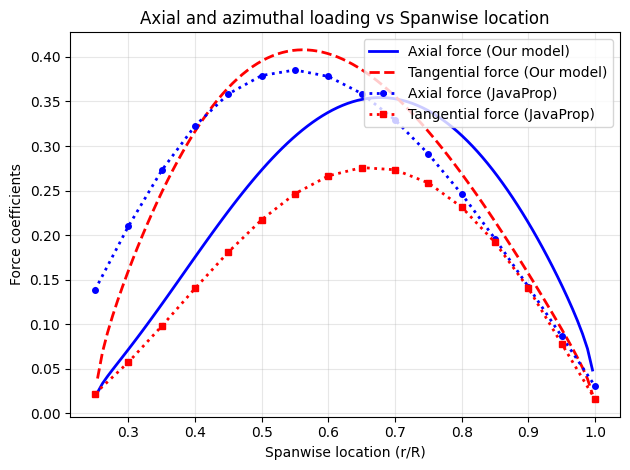

In [7]:
forces_span_dist(exp_df=dfSing, val_df=dfJavaSing,save=False)

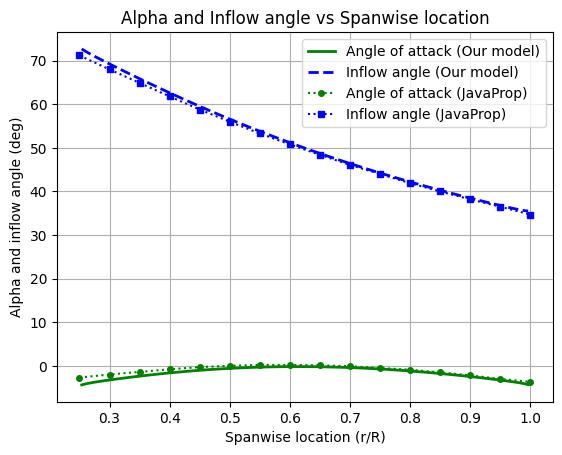

In [8]:
alpha_span_dist(exp_df=dfSing, val_df=dfJavaSing,save=False)

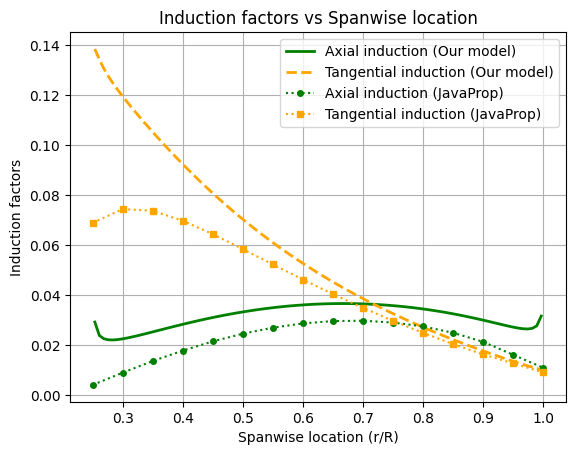

In [9]:
induction_span_dist(exp_df=dfSing, val_df=dfJavaSing,save=False)

In [11]:
polar_txt = np.loadtxt('ARAD6pct_polar.txt',skiprows=3)
polar_data = {}
polar_data["alpha"] = polar_txt[:,0]
polar_data["Cl"]    = polar_txt[:,1]
polar_data["Cd"]    = polar_txt[:,2]
print(polar_data["alpha"])

[-8.75 -8.5  -8.25 -8.   -7.75 -7.5  -7.25 -7.   -6.75 -6.5  -6.25 -6.
 -5.75 -5.5  -5.25 -5.   -4.75 -4.5  -4.25 -4.   -3.75 -3.5  -3.25 -3.
 -2.75 -2.5  -2.25 -2.   -1.75 -1.5  -1.25 -1.   -0.75 -0.5  -0.25  0.
  0.25  0.5   0.75  1.    1.25  1.5   1.75  2.    2.25  2.5   2.75  3.
  3.25  3.5   3.75  4.    4.25  4.5   4.75  5.    5.25  5.5   5.75  6.
  6.25  6.5   6.75  7.    7.25  7.5   7.75  8.    8.25  8.5   8.75  9.
  9.25  9.5   9.75 10.   10.25 10.5  10.75 11.   11.25 11.5  11.75 12.
 12.25 12.5  12.75 13.   13.25 13.5  13.75 14.   14.25 14.5  14.75 15.
 15.25 15.5  15.75 16.   16.25 16.5  16.75 17.   17.25 17.5 ]
